In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("samplesuperstore.csv")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [9]:
df['Month'] = df['Order Date'].dt.month

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
monthly_sales = df.groupby('Month')['Sales'].sum()

In [12]:
print(monthly_sales)

Month
1      96069.5156
2      59751.2514
3     210672.0868
4     138098.7486
5     158765.0337
6     153459.9973
7     149001.7130
8     161821.9150
9     308883.6697
10    207126.2567
11    352665.9910
12    330218.1755
Name: Sales, dtype: float64


<Axes: xlabel='Month'>

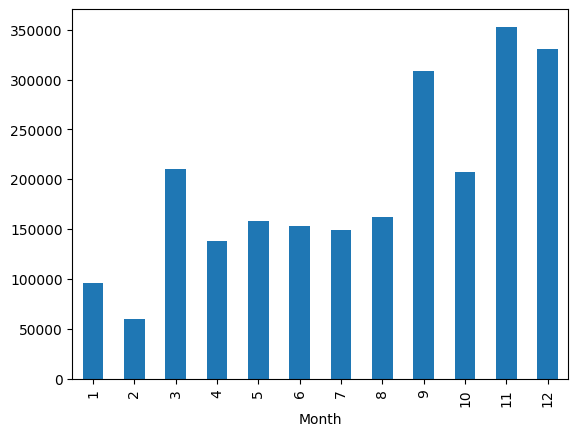

In [13]:
monthly_sales.plot(kind='bar')

Text(0.5, 1.0, 'Monthly Sales')

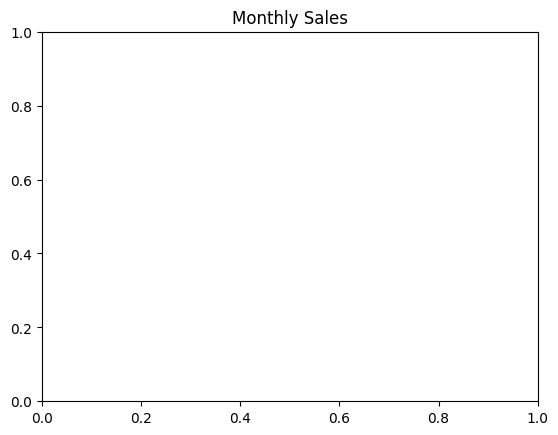

In [14]:
plt.title("Monthly Sales")

In [15]:
plt.show()

In [16]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

In [17]:
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


<Axes: ylabel='Product Name'>

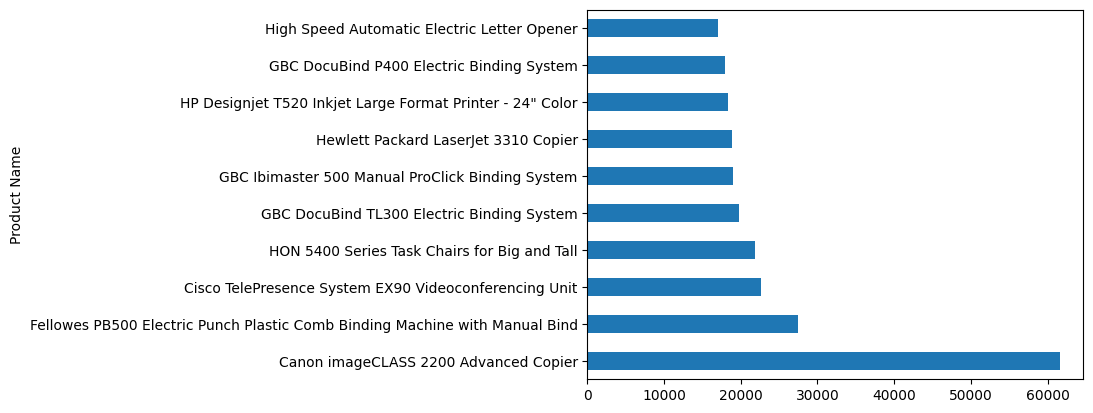

In [18]:
top_products.plot(kind='barh')

Text(0.5, 1.0, 'Top 10 Products')

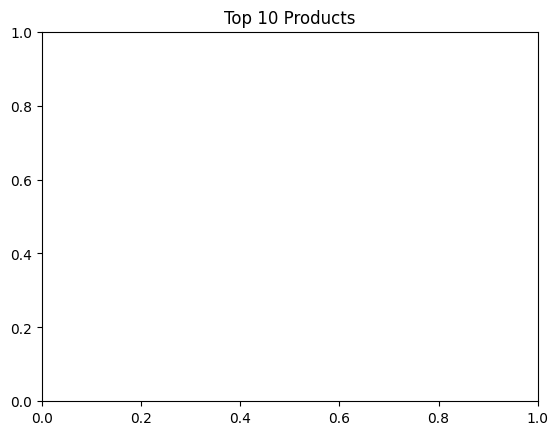

In [19]:
plt.title("Top 10 Products")

In [20]:
plt.show()

In [21]:
profit_trend = df.groupby('Month')['Profit'].sum()


In [22]:
print(profit_trend)

Month
1      9497.2501
2     10294.6107
3     29345.0405
4     11625.5223
5     22850.0324
6     21508.2067
7     14013.5496
8     22942.4239
9     37234.5608
10    33214.5143
11    35541.2553
12    44229.8480
Name: Profit, dtype: float64


<Axes: xlabel='Month'>

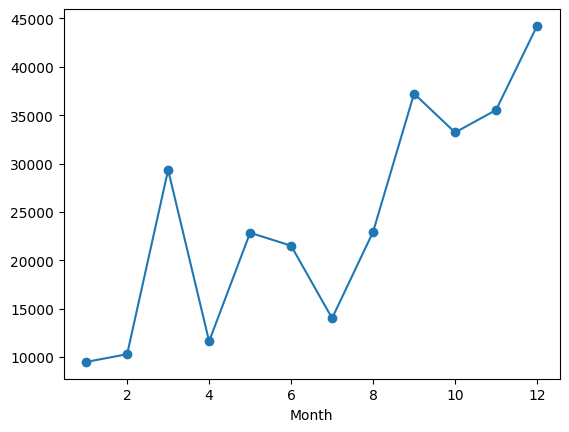

In [23]:
profit_trend.plot(marker='o')

Text(0.5, 1.0, 'Profit Trend')

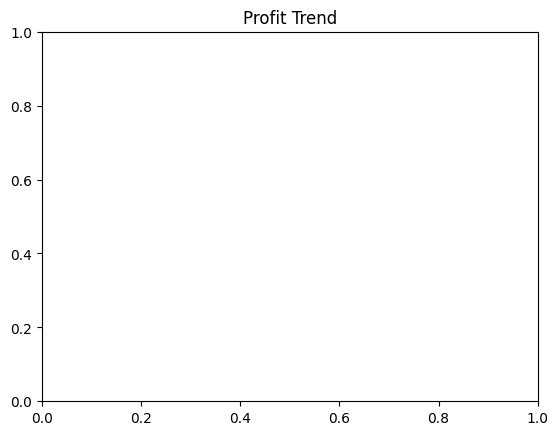

In [24]:
plt.title("Profit Trend")

In [25]:
plt.show()

In [26]:
df.to_csv("clean_sales_data.csv", index=False)